# Draft figures for first paper


Aim: to keep the notebook as clean as possible. 

In [1]:
import os,glob
import xarray as xr
import numpy as np
import pandas as pd
import pyreadr # to read .rds files
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
path_rds = "/Users/ud4/Documents/FACEMDS/Models/obs_data"
#path_save_results = "/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/Evaluation_Paper_Dir/Results"
path_save_results = "/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/FATESResultsSharing/Results"

In [3]:
# Load the RDS file
# read mean annual
result = pyreadr.read_r(f'{path_rds}/OBS_ax.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data = result[None]  # None is the key for the single R object in the file

# SE
result = pyreadr.read_r(f'{path_rds}/OBS_ase.rds')
my_data_se = result[None]  # None is the key for the single R object in the file

# plot obs? 
obs_plot = 1 # 0,1

In [4]:
#global variables
sites= ("US-ORN", "US-DUK")
sim_cases = [
            "RD",
            "ECA",
            #"COnly",
]
run_cases = ["aCO2", "eCO2"]

In [20]:
parameter_index = 1
total_params_members = 125 # actual 125
ranges_pars = range((parameter_index)*125+1,(parameter_index)*125+total_params_members)

parm_names = [
    "d2bl1",
    "Mbr_leaf",
    "Mbr_nonleaf",
    "store_ovrflw",
    "vmax_nh4"
]
    

Best_Parms = {}
for site in sites:
    Best_Parms[site]={}
    for sim_case in sim_cases:
        Best_Parms[site][sim_case] = {}

site = "US-ORN"; sim_case = "RD"
Best_Parms[site][sim_case][parm_names[0]] = 0.1272
Best_Parms[site][sim_case][parm_names[1]] = 7.0035E-06
Best_Parms[site][sim_case][parm_names[2]] = 1.6262E-06
Best_Parms[site][sim_case][parm_names[3]] = 10.4027
Best_Parms[site][sim_case][parm_names[4]] = 7.3969E-07

site = "US-ORN"; sim_case = "ECA"
Best_Parms[site][sim_case][parm_names[0]] = 0.0812
Best_Parms[site][sim_case][parm_names[1]] = 1.1875E-7
Best_Parms[site][sim_case][parm_names[2]] = 2.2262E-06
Best_Parms[site][sim_case][parm_names[3]] = 13.99
Best_Parms[site][sim_case][parm_names[4]] = 2.0057E-05

site = "US-DUK"; sim_case = "RD"
Best_Parms[site][sim_case][parm_names[0]] = 0.1122
Best_Parms[site][sim_case][parm_names[1]] = 5.6621E-06
Best_Parms[site][sim_case][parm_names[2]] = 1.7833E-06
Best_Parms[site][sim_case][parm_names[3]] = 11
Best_Parms[site][sim_case][parm_names[4]] = 8.9882E-07

site = "US-DUK"; sim_case = "ECA"
Best_Parms[site][sim_case][parm_names[0]] = 0.111
Best_Parms[site][sim_case][parm_names[1]] = 4.5873E-6
Best_Parms[site][sim_case][parm_names[2]] = 1.7492E-06
Best_Parms[site][sim_case][parm_names[3]] = 4.04
Best_Parms[site][sim_case][parm_names[4]] = 1.3041E-05


In [6]:
case_id = "FACE_r250224_RDornl_enTune"
sim_case = "RD"
run_case = "aCO2"
l_fnames = {}



for site in sites:
    for sim_case in sim_cases:
        for run_case in run_cases:
            if (sim_case == "RD") and (site == "US-ORN"): case_id = "FACE_r250224_RDornl_enTune"
            elif (sim_case == "RD") and (site == "US-DUK"): case_id = "FACE_r250224_RDduke_enTune"
            elif (sim_case == "ECA") and (site == "US-ORN"): case_id = "FACE_r250224_ECAornl_enTune"
            elif (sim_case == "ECA") and (site == "US-DUK"): case_id = "FACE_r250224_ECAduke_enTune"
            for i in ranges_pars:
                #print (f"{path_in}{case_id}_{sim_case}_processed/{case_id}_{sim_case}_{site}_{run_case}_{'g{:05d}'.format(i)}.nc")
                l_fnames[f"{site}_{sim_case}_{run_case}_{'g{:05d}'.format(i)}"] = f"{path_in}{case_id}_{sim_case}_processed/{case_id}_{sim_case}_{site}_{run_case}_{'g{:05d}'.format(i)}.nc"
                #print ( f"{site}_{sim_case}_{run_case}_{'g{:05d}'.format(i)}", f"{path_in}{case_id}_{sim_case}_processed/{case_id}_{sim_case}_{site}_{run_case}_{'g{:05d}'.format(i)}.nc")
    
ds = {}
for idx, key in enumerate(l_fnames.keys()):
    try:
        ds[key] = xr.open_mfdataset(l_fnames[key])
        #print("reading ... ", key)
    except:
        print("reading fail ", key)

reading fail  US-DUK_RD_aCO2_g00213
reading fail  US-DUK_RD_aCO2_g00216
reading fail  US-DUK_RD_eCO2_g00213
reading fail  US-DUK_RD_eCO2_g00216


## Fig showing eCO2 response for NPP, Nup, CUE, NUP

In [7]:
    
markers_list = [".", "<", "o","^",".", "<", "o","^"]
colors_list = ["red", "green", "blue", "yellow","red", "green", "blue", "yellow"] 

def tmp_legend_name (key):
    return key.replace("FACE_1PFT_r250210_Best_Cal_", "")
    
# How long do you want the simulation plots?
max_r_years = 150
if run_case == "spins":
    output_freq = "yearly" # spins
    multiply_factor = 1 # 365 for daily output; else 1 for yearly
else:
    output_freq = "daily" # spins
    multiply_factor = 365
    if "CO2" in run_case:
        max_r_years = 12+5

In [8]:
# dataframe of selected colms 
# relevant columns
rel_cols = ["YEAR", "co2", "site", "NPP", "NUP"]
# if you want to save the filtered dataframe to CSV
#my_data[rel_cols].to_csv("tmp/obs_a.csv")
df_obs_ax = my_data[rel_cols]
df_obs_ase = my_data_se[rel_cols]

NPP_units = "gC m-2 y-1"
NUP_units = "gN m-2 y-1"

# Filter the dataset to keep only rows where site is 'ORNL' or 'DUKE'
df_obs_ax_site = df_obs_ax[df_obs_ax['site'].isin(['ORNL', 'DUKE'])]
df_obs_ase_site = df_obs_ase[df_obs_ase['site'].isin(['ORNL', 'DUKE'])]

filter_co2 = df_obs_ase_site["co2"] == "AMB"
filter_site = df_obs_ase_site["site"] == "ORNL"
df_obs_ase_site[filter_co2][filter_site]

# arrange data into dict!
dict_obs_ax = {}
sites_o= ("ORNL", "DUKE" )
#sites_o= ( "ORNL", )

CO2_cases  = ("AMB", "ELE" )
dict_obs_ax = {}
dict_obs_ase = {} # standard error
dict_obs_aserel = {} #rel standard error = Val SE/Var
for site in sites_o:
    dict_obs_ax    [site] = {}
    dict_obs_ase   [site] = {}
    dict_obs_aserel [site] = {}
    for co2_case in CO2_cases:
        # selected values from mean
        filter_co2 = df_obs_ax_site["co2"] == co2_case
        filter_site = df_obs_ax_site["site"] == site
        dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
        # selected values from standard error
        filter_co2 = df_obs_ase_site["co2"] == co2_case
        filter_site = df_obs_ase_site["site"] == site
        dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
        dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
        dict_obs_aserel[site][co2_case][["NPP", "NUP"]] = df_obs_ase_site[filter_co2][filter_site][["NPP", "NUP"]]/df_obs_ax_site[filter_co2][filter_site][["NPP", "NUP"]]

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_29463/2440484563.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_29463/2440484563.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_29463/2440484563.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_29463/2440484563.py:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_29463/2440484563.py:43: UserWarn

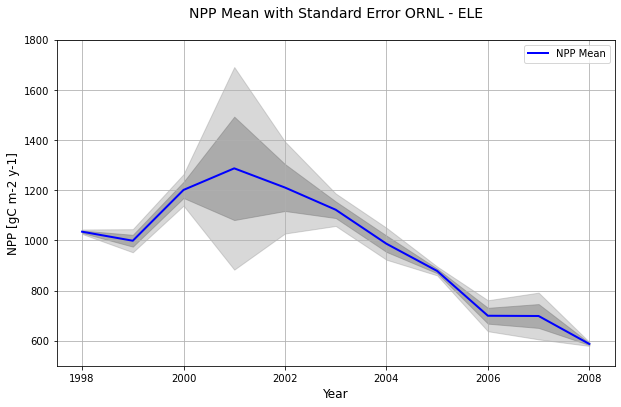

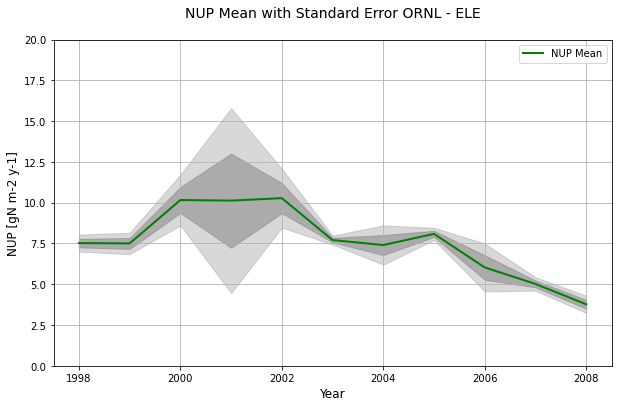

In [9]:

site = "ORNL"
co2_case = "ELE"

Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

mean_nup = Mean_DF['NUP']
se_nup = Standard_error_DF['NUP']

# Create the figure and axis
plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='NPP Mean', color='blue', lw=2)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color='gray', alpha=0.3)

# Add labels and title
plt.xlabel('Year',fontsize=12 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=12)
plt.title(f'NPP Mean with Standard Error {site} - {co2_case}\n', fontsize= 14)
plt.legend()
plt.ylim (500, 1800) 
# Show grid and the plot
plt.grid(True)
# Display the plot
plt.show()


plt.figure(figsize=(10, 6))
# Plot NUP with shaded error bars (optional, if you want it on the same plot)
plt.plot(years, mean_nup, label='NUP Mean', color='green', lw=2)
plt.fill_between(years, mean_nup - se_nup, mean_nup + se_nup, color='gray', alpha=0.5)
plt.fill_between(years, mean_nup - se_nup*1.96, mean_nup + se_nup*1.96, color='gray', alpha=0.3)

plt.xlabel('Year', fontsize=12)
plt.ylabel(f'NUP [{NUP_units}]', fontsize=12)
plt.title(f'NUP Mean with Standard Error {site} - {co2_case}\n', fontsize= 14)
plt.legend()
plt.ylim (0, 20) 
# Show grid and the plot
plt.grid(True)
plt.show()

In [10]:
ds[key]

<xarray.Dataset>
Dimensions:                           (fates_levscag: 91, fates_levscpf: 13, fates_levcapf: 2, fates_levcnlf: 60, fates_levcnlfpf: 60, fates_levscagpf: 91, fates_levagepft: 7, fates_levelpft: 3, fates_levelcwd: 12, fates_levelage: 21, fates_levagefuel: 42, fates_levcdsc: 26, fates_levcdpf: 26, time: 4380, hist_interval: 2, lndgrid: 1, levgrnd: 15, levlak: 10, fates_levscls: 13, fates_levage: 7, fates_levheight: 6, fates_levpft: 1, fates_levcan: 2, fates_levelem: 3, levsoi: 10, fates_levfuel: 6, fates_levcacls: 2, levdcmp: 15, ltype: 9, natpft: 15)
Coordinates: (12/13)
  * time                              (time) object 1996-01-01 00:00:00 ... 2...
  * levgrnd                           (levgrnd) float64 0.007101 ... 35.18
  * levlak                            (levlak) float64 0.05 0.6 ... 34.33 44.78
  * fates_levscls                     (fates_levscls) float64 0.0 ... 9.969e+36
  * fates_levage                      (fates_levage) float64 0.0 1.0 ... 50.0
  * fates_levheight                   (fates_levheight) float64 0.0 0.1 ... 10.0
    ...                                ...
  * fates_levcan                      (fates_levcan) int32 1 2
  * fates_levelem                     (fates_levelem) int32 1 4 5
  * levsoi                            (levsoi) float64 0.007101 ... 2.865
  * fates_levfuel                     (fates_levfuel) int32 1 2 3 4 5 6
  * fates_levcacls                    (fates_levcacls) float64 0.0 5.0
  * levdcmp                           (levdcmp) float64 0.007101 ... 35.18
Dimensions without coordinates: fates_levscag, fates_levscpf, fates_levcapf, fates_levcnlf, fates_levcnlfpf, fates_levscagpf, fates_levagepft, fates_levelpft, fates_levelcwd, fates_levelage, fates_levagefuel, fates_levcdsc, fates_levcdpf, hist_interval, lndgrid, ltype, natpft
Data variables: (12/660)
    fates_scmap_levscag               (fates_levscag) int32 dask.array<chunksize=(91,), meta=np.ndarray>
    fates_agmap_levscag               (fates_levscag) int32 dask.array<chunksize=(91,), meta=np.ndarray>
    fates_pftmap_levscpf              (fates_levscpf) int32 dask.array<chunksize=(13,), meta=np.ndarray>
    fates_scmap_levscpf               (fates_levscpf) int32 dask.array<chunksize=(13,), meta=np.ndarray>
    fates_pftmap_levcapf              (fates_levcapf) int32 dask.array<chunksize=(2,), meta=np.ndarray>
    fates_camap_levcapf               (fates_levcapf) int32 dask.array<chunksize=(2,), meta=np.ndarray>
    ...                                ...
    WTGQ                              (time, lndgrid) float32 dask.array<chunksize=(4380, 1), meta=np.ndarray>
    ZBOT                              (time, lndgrid) float32 dask.array<chunksize=(4380, 1), meta=np.ndarray>
    ZWT                               (time, lndgrid) float32 dask.array<chunksize=(4380, 1), meta=np.ndarray>
    ZWT_CH4_UNSAT                     (time, lndgrid) float32 dask.array<chunksize=(4380, 1), meta=np.ndarray>
    ZWT_PERCH                         (time, lndgrid) float32 dask.array<chunksize=(4380, 1), meta=np.ndarray>
    o2_decomp_depth_unsat             (time, levgrnd, lndgrid) float32 dask.array<chunksize=(4380, 15, 1), meta=np.ndarray>

In [11]:
# Set background color
plt.rcParams['figure.facecolor'] = '#F5F5DC'  # Beige background for the entire figure
plt.rcParams['axes.facecolor'] = '#F5F5DC'    # Beige background for the plot area

In [12]:
ds.keys()

dict_keys(['US-ORN_RD_aCO2_g00126', 'US-ORN_RD_aCO2_g00127', 'US-ORN_RD_aCO2_g00128', 'US-ORN_RD_aCO2_g00129', 'US-ORN_RD_aCO2_g00130', 'US-ORN_RD_aCO2_g00131', 'US-ORN_RD_aCO2_g00132', 'US-ORN_RD_aCO2_g00133', 'US-ORN_RD_aCO2_g00134', 'US-ORN_RD_aCO2_g00135', 'US-ORN_RD_aCO2_g00136', 'US-ORN_RD_aCO2_g00137', 'US-ORN_RD_aCO2_g00138', 'US-ORN_RD_aCO2_g00139', 'US-ORN_RD_aCO2_g00140', 'US-ORN_RD_aCO2_g00141', 'US-ORN_RD_aCO2_g00142', 'US-ORN_RD_aCO2_g00143', 'US-ORN_RD_aCO2_g00144', 'US-ORN_RD_aCO2_g00145', 'US-ORN_RD_aCO2_g00146', 'US-ORN_RD_aCO2_g00147', 'US-ORN_RD_aCO2_g00148', 'US-ORN_RD_aCO2_g00149', 'US-ORN_RD_aCO2_g00150', 'US-ORN_RD_aCO2_g00151', 'US-ORN_RD_aCO2_g00152', 'US-ORN_RD_aCO2_g00153', 'US-ORN_RD_aCO2_g00154', 'US-ORN_RD_aCO2_g00155', 'US-ORN_RD_aCO2_g00156', 'US-ORN_RD_aCO2_g00157', 'US-ORN_RD_aCO2_g00158', 'US-ORN_RD_aCO2_g00159', 'US-ORN_RD_aCO2_g00160', 'US-ORN_RD_aCO2_g00161', 'US-ORN_RD_aCO2_g00162', 'US-ORN_RD_aCO2_g00163', 'US-ORN_RD_aCO2_g00164', 'US-ORN_RD_aCO

In [13]:
run_cases

['aCO2', 'eCO2']

fail.. US-DUK_RD_aCO2_g00213
fail.. US-DUK_RD_aCO2_g00216
fail.. US-DUK_RD_eCO2_g00213
fail.. US-DUK_RD_eCO2_g00216
/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/FATESResultsSharing/Results/test_NPP_Best_Parms_Cal_20p_US-DUK_RD.pdf
/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/FATESResultsSharing/Results/test_NPP_Best_Parms_Cal_20p_US-DUK_ECA.pdf


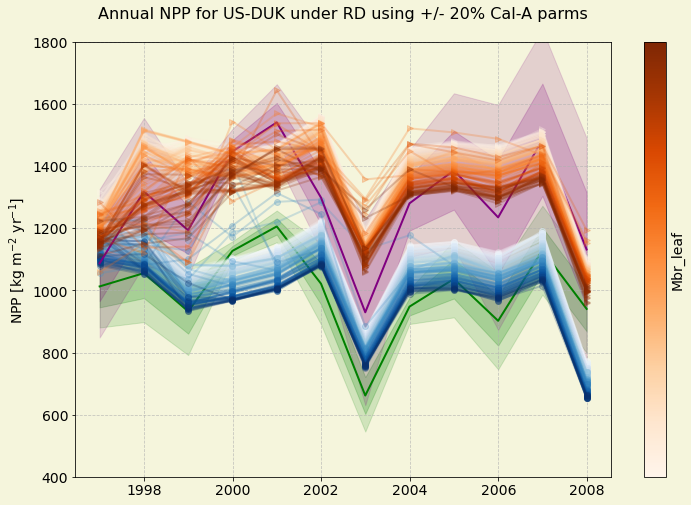

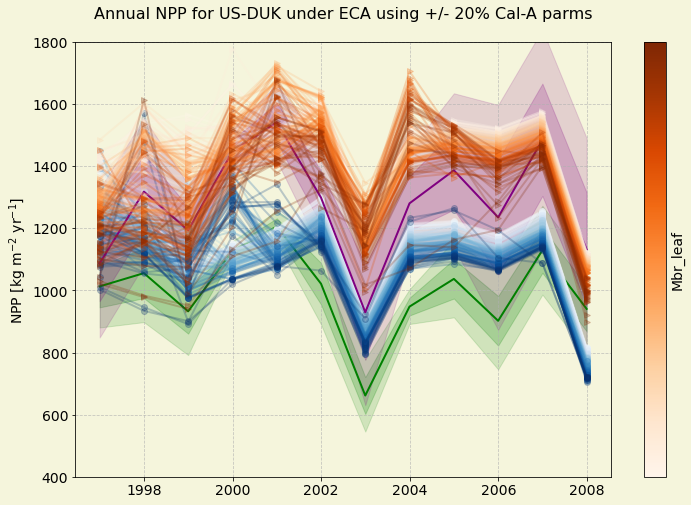

In [15]:
vars_names = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )
select_site = "US-ORN"; site_name = "ORNL"
select_site = "US-DUK"; site_name = "DUKE"
#for site in sites:
if True:
    site = select_site
    for sim_case in sim_cases:
    #if True:
        #if sim_case == sim_cases[0]: continue
        co2_case_plotted = {"AMB": False, "ELE": False}
        plt.figure(figsize=(12,8))
        for run_case in run_cases:
            for var in vars_names:
                for i in ranges_pars:
                    try:
                        key = f"{site}_{sim_case}_{run_case}_{'g{:05d}'.format(i)}"
                        #if i ==15: break
                        if site == "US-ORN":
                            time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                        else:
                            time = pd.date_range("1996-01-01", "2007-12-31", freq="A")  # Monthly data
                        if "aCO2" in key:
                            #color_line = "b"
                            cmap = plt.cm.Blues  # Choose a colormap
                            norm = mcolors.Normalize(vmin=min(ranges_pars), vmax=max(ranges_pars))  # Normalize color scale
                            # Assign gradient color based on index
                            color_line = cmap(norm(i))
                            marker_line = "o"
                            co2_case = "AMB"
                            tmp_case = "aCO2"
                            color_obs = "green"
                        if "eCO2" in key:
                            #color_line = "r"
                            cmap = plt.cm.Oranges  # Choose a colormap
                            norm = mcolors.Normalize(vmin=min(ranges_pars), vmax=max(ranges_pars))  # Normalize color scale
                            # Assign gradient color based on index
                            #color_line = cmap(norm(idx-total_params_members)) # hack to reset index of color range. 
                            color_line = cmap(norm(i))
                            marker_line = ">"
                            co2_case = "ELE"
                            tmp_case = "eCO2"
                            color_obs = "purple"
                            ran_twice = 0  # Flag to track execution
                        if obs_plot == 1 and not co2_case_plotted[co2_case]:
                            Mean_DF = dict_obs_ax[site_name][co2_case]
                            Standard_error_DF = dict_obs_ase[site_name][co2_case]
                            # Extracting the relevant columns
                            years = Mean_DF['YEAR']
                            mean_npp = Mean_DF['NPP']
                            se_npp = Standard_error_DF['NPP']
                            # Plot NPP with shaded error bars
                            plt.plot(time, mean_npp, label=f'{tmp_case}_NPP_Obs', color=color_obs, lw=2)
                            plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'{tmp_case}_NPP_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                            plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                            #ran_twice +=1
                            # Mark this CO2 case as plotted
                            co2_case_plotted[co2_case] = True
                        if var =="FATES_NPP-FATES_EXCESS_RESP":
                            tmp_var = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000   
                            plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                        if var == "NPP_alloc":
                            tmp_var = ( 
                            ds[key]['FATES_CROOT_ALLOC'] +
                            ds[key]['FATES_FROOT_ALLOC'] +
                            ds[key]['FATES_LEAF_ALLOC'] +
                            ds[key]['FATES_SEED_ALLOC'] +
                            ds[key]['FATES_STEM_ALLOC'] 
                        )*24*3600*365*1000   
                            plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             color = color_line,
                             marker = marker_line,
                             alpha=.25, linewidth=2)
                    except:
                        print ("fail..", key)
        plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
        plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
        #plt.legend(fontsize=14,loc="upper right")
        plt.ylabel(r"NPP [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
        plt.xticks(fontsize=14)  # Increase x-axis tick font size
        plt.yticks(fontsize=14)  # Increase y-axis tick font size
        plt.ylim(400,1800)
        plt.title(f"Annual NPP for {select_site} under {sim_case} using +/- 20% Cal-A parms\n",fontsize=16)
                    
        # Add colorbar to indicate simulation index mapping
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm)
        cbar.set_label(label=f"{parm_names[parameter_index]}", fontsize=14) 
        # Define tick mapping
        original_ticks = np.linspace(0, total_params_members, 6)  # Example original tick positions (normalized scale)
        mean_parm_val = Best_Parms[site][sim_case][parm_names[parameter_index]]
        mapped_parm_values = np.linspace(mean_parm_val*.8,mean_parm_val*1.2, 6)

        # Apply mapping
        cbar.set_ticks(original_ticks)
        cbar.set_ticklabels(mapped_parm_values)
        cbar.ax.tick_params(labelsize=12)
        print (f"{path_save_results}/test_NPP_Best_Parms_Cal_20p_{select_site}_{sim_case}.pdf")
        plt.savefig(
            f"{path_save_results}/test_NPP_Best_Parms_{parm_names[parameter_index]}_20p_{select_site}_{sim_case}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        


In [84]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
vars_names = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )
select_site = "US-DUK"; site_name = "DUKE"
#for site in sites:
if True:
    site = select_site
    for sim_case in sim_cases:
    #if True:
        sim_case = sim_cases[1]
        co2_case_plotted = {"AMB": False, "ELE": False}
        plt.figure(figsize=(12,8))
        t_idx = 0
        for run_case in run_cases:
            for var in vars_names:
                for i in ranges_pars:
                    key = f"{site}_{sim_case}_{run_case}_{'g{:05d}'.format(i)}"
                    time = pd.date_range("1996-01-01", "2007-12-31", freq="A")  # Monthly data
                    if "aCO2" in key:
                        #color_line = "b"
                        cmap = plt.cm.Blues  # Choose a colormap
                        norm = mcolors.Normalize(vmin=0, vmax=total_params_members)  # Normalize color scale
                        # Assign gradient color based on index
                        color_line = cmap(norm(i))
                        t_idx+=1
                        marker_line = "o"
                        co2_case = "AMB"
                        tmp_case = "aCO2"
                        color_obs = "green"
                    if "eCO2" in key:
                        #color_line = "r"
                        cmap = plt.cm.Oranges  # Choose a colormap
                        norm = mcolors.Normalize(vmin=0, vmax=total_params_members)  # Normalize color scale
                        # Assign gradient color based on index
                        #color_line = cmap(norm(idx-total_params_members)) # hack to reset index of color range. 
                        color_line = cmap(norm(i))
                        t_idx+=1
                        marker_line = ">"
                        co2_case = "ELE"
                        tmp_case = "eCO2"
                        color_obs = "purple"
                        ran_twice = 0  # Flag to track execution
                    if obs_plot == 1 and not co2_case_plotted[co2_case]:
                        Mean_DF = dict_obs_ax[site_name][co2_case]
                        Standard_error_DF = dict_obs_ase[site_name][co2_case]
                        # Extracting the relevant columns
                        years = Mean_DF['YEAR']
                        mean_npp = Mean_DF['NPP']
                        se_npp = Standard_error_DF['NPP']
                        # Plot NPP with shaded error bars
                        plt.plot(time, mean_npp, label=f'{tmp_case}_NPP_Obs', color=color_obs, lw=2)
                        plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'{tmp_case}_NPP_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                        plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                        #ran_twice +=1
                        # Mark this CO2 case as plotted
                        co2_case_plotted[co2_case] = True
                    if var =="FATES_NPP-FATES_EXCESS_RESP":
                        tmp_var = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000   
                        plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    if var == "NPP_alloc":
                        tmp_var = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                        plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                    plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                    #plt.legend(fontsize=14,loc="upper right")
                    plt.ylabel(r"NPP [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
                    plt.xticks(fontsize=14)  # Increase x-axis tick font size
                    plt.yticks(fontsize=14)  # Increase y-axis tick font size
                    plt.ylim(400,1800)
                    plt.title(f"Annual NPP for {select_site} under {sim_case} using +/- 20% Cal-A parms\n",fontsize=16)

In [ ]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )
select_site = "US-ORN"
site = "ORNL"
li = 0 # for legend index
#for sim_case in sim_cases:
if True:
    sim_case = sim_cases[0]
    #ran_twice = 0  # Flag to track execution
    # Dictionary to track executed plots for each CO2 case
    co2_case_plotted = {"AMB": False, "ELE": False}
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in vars:
        t_idx = 0
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if f"{select_site}" in key: 
                time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    #color_line = "b"
                    cmap = plt.cm.Blues  # Choose a colormap
                    norm = mcolors.Normalize(vmin=0, vmax=total_params_members)  # Normalize color scale
                    # Assign gradient color based on index
                    color_line = cmap(norm(t_idx))
                    t_idx+=1
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = "green"
                if "eCO2" in key:
                    #color_line = "r"
                    cmap = plt.cm.Oranges  # Choose a colormap
                    norm = mcolors.Normalize(vmin=0, vmax=total_params_members)  # Normalize color scale
                    # Assign gradient color based on index
                    #color_line = cmap(norm(idx-total_params_members)) # hack to reset index of color range. 
                    color_line = cmap(norm(t_idx-total_params_members))
                    t_idx+=1
                    marker_line = ">"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = "purple"
                    ran_twice = 0  # Flag to track execution
                #if (obs_plot ==1) and (ran_twice<2):
                if obs_plot == 1 and not co2_case_plotted[co2_case]:
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    years = Mean_DF['YEAR']
                    mean_npp = Mean_DF['NPP']
                    se_npp = Standard_error_DF['NPP']
                    # Plot NPP with shaded error bars
                    plt.plot(time, mean_npp, label=f'{tmp_case}_NPP_Obs', color=color_obs, lw=2)
                    plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'{tmp_case}_NPP_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                    plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                    #ran_twice +=1
                    # Mark this CO2 case as plotted
                    co2_case_plotted[co2_case] = True
                    
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)

                if False:
                    #plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    #plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                #plt.legend(fontsize=14,loc="upper right")
                plt.ylabel(r"NPP [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(400,1800)
                plt.title(f"Annual NPP for {select_site} under {sim_case} using Cal-A parms\n",fontsize=16)
                #li+=1 # for legend index updating for a site
                
                # Add colorbar to indicate simulation index mapping
                #sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                #sm.set_array([])
                #cbar = plt.colorbar(sm, label="Simulation Index")

    print ("fig end",sim_case,select_site)
    print (f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}.pdf")
    #plt.savefig(f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
        
    

In [ ]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )
select_site = "US-ORN"
site = "ORNL"
li = 0 # for legend index
#for sim_case in sim_cases:
if True:
    sim_case = sim_cases[0]
    #ran_twice = 0  # Flag to track execution
    # Dictionary to track executed plots for each CO2 case
    co2_case_plotted = {"AMB": False, "ELE": False}
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in vars:
        t_idx = 0
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if f"{select_site}" in key: 
                time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    #color_line = "b"
                    cmap = plt.cm.Blues  # Choose a colormap
                    norm = mcolors.Normalize(vmin=0, vmax=total_params_members)  # Normalize color scale
                    # Assign gradient color based on index
                    color_line = cmap(norm(t_idx))
                    t_idx+=1
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = "green"
                if "eCO2" in key:
                    #color_line = "r"
                    cmap = plt.cm.Oranges  # Choose a colormap
                    norm = mcolors.Normalize(vmin=0, vmax=total_params_members)  # Normalize color scale
                    # Assign gradient color based on index
                    #color_line = cmap(norm(idx-total_params_members)) # hack to reset index of color range. 
                    color_line = cmap(norm(t_idx-total_params_members))
                    t_idx+=1
                    marker_line = ">"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = "purple"
                    ran_twice = 0  # Flag to track execution
                #if (obs_plot ==1) and (ran_twice<2):
                if obs_plot == 1 and not co2_case_plotted[co2_case]:
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    years = Mean_DF['YEAR']
                    mean_npp = Mean_DF['NPP']
                    se_npp = Standard_error_DF['NPP']
                    # Plot NPP with shaded error bars
                    plt.plot(time, mean_npp, label=f'{tmp_case}_NPP_Obs', color=color_obs, lw=2)
                    plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'{tmp_case}_NPP_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                    plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                    #ran_twice +=1
                    # Mark this CO2 case as plotted
                    co2_case_plotted[co2_case] = True
                    
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)

                if False:
                    #plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    #plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                #plt.legend(fontsize=14,loc="upper right")
                plt.ylabel(r"NPP [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(400,1800)
                plt.title(f"Annual NPP for {select_site} under {sim_case} using Cal-A parms\n",fontsize=16)
                #li+=1 # for legend index updating for a site
                
                # Add colorbar to indicate simulation index mapping
                #sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                #sm.set_array([])
                #cbar = plt.colorbar(sm, label="Simulation Index")

    print ("fig end",sim_case,select_site)
    print (f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}.pdf")
    #plt.savefig(f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
        
    

In [ ]:
obs_plot


In [ ]:
break

In [ ]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )
select_site = "US-ORN"
site = "ORNL"


li = 0 # for legend index
for sim_case in sim_cases:
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in vars:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if f"{select_site}" in key: 
                time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    color_line = "b"
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = "green"
                if "eCO2" in key:
                    color_line = "r"
                    marker_line = ">"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = "purple"
                if (obs_plot ==1) and (ran_twice<2):
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    years = Mean_DF['YEAR']
                    mean_npp = Mean_DF['NPP']
                    se_npp = Standard_error_DF['NPP']
                    # Plot NPP with shaded error bars
                    plt.plot(time, mean_npp, label=f'{tmp_case}_NPP_Obs', color=color_obs, lw=2)
                    plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'{tmp_case}_NPP_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                    plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                    ran_twice +=1
                    
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)

                if False:
                    #plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    #plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14,loc="upper right")
                plt.ylabel(r"NPP [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(400,1800)
                plt.title(f"Annual NPP for {select_site} under {sim_case} using Cal-A parms\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print ("fig end",sim_case,select_site)
    print (f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}.pdf")
    #plt.savefig(f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
        
    

In [ ]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )
select_site = "US-DUK"
site = "DUKE"

li = 0 # for legend index
for sim_case in sim_cases:
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in vars:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if f"{select_site}" in key: 
                time = pd.date_range("1996-01-01", "2007-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    color_line = "b"
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = "green"
                if "eCO2" in key:
                    color_line = "r"
                    marker_line = ">"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = "purple"
                if (obs_plot ==1) and (ran_twice<2):
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    years = Mean_DF['YEAR']
                    mean_npp = Mean_DF['NPP']
                    se_npp = Standard_error_DF['NPP']
                    # Plot NPP with shaded error bars
                    plt.plot(time, mean_npp, label=f'{tmp_case}_NPP_Obs', color=color_obs, lw=2)
                    plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'{tmp_case}_NPP_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                    plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                    ran_twice +=1
                    
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)

                if False:
                    #plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    #plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14,loc="upper center",  ncol=2)
                plt.ylabel(r"NPP [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(600,2100)
                plt.title(f"Annual NPP for {select_site} under {sim_case} using Cal-A parms\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print ("fig end",sim_case,select_site)
    print (f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}.pdf")
    plt.savefig(f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
        
    

In [ ]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )
select_site = "US-ORN"
site = "ORNL"
li = 0 # for legend index
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12,6))
    for var in vars:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if f"{select_site}" in key: 
                time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                color_obs = "k"
                
                if (obs_plot ==1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = Mean_DF1[["YEAR","NPP", "NUP"]] - Mean_DF0[["YEAR","NPP", "NUP"]]
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(drop=True)
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(drop=True)

                    Standard_error_DF = ((Standard_error_DF1[["YEAR","NPP", "NUP"]])**2 + (Standard_error_DF0[["YEAR","NPP", "NUP"]])**2)**.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]

                    # Extracting the relevant columns
                    years = Mean_DF['YEAR']
                    mean_npp = Mean_DF['NPP']
                    se_npp = Standard_error_DF['NPP']
                    # Plot NPP with shaded error bars
                    plt.plot(time, mean_npp, label=f'Response_NPP_Obs', color=color_obs, lw=2)
                    plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'Response_NPP_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                    plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                    
                    ran_once = True
                    
                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000  
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (ds[key_eCO2][var.split('-')[0]] - ds[key_eCO2][var.split('-')[1]])*24*3600*365*1000 
                    
                    plt.plot(time, (tmp_var_e-tmp_var_a).groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1].replace("aCO2", "Response")+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = ( 
                        ds[key_eCO2]['FATES_CROOT_ALLOC'] +
                        ds[key_eCO2]['FATES_FROOT_ALLOC'] +
                        ds[key_eCO2]['FATES_LEAF_ALLOC'] +
                        ds[key_eCO2]['FATES_SEED_ALLOC'] +
                        ds[key_eCO2]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    plt.plot(time, (tmp_var_e-tmp_var_a).groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1].replace("aCO2", "Response")+'_'+var,
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)
                if False:
                    #plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    #plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"NPP Response [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(0,500)
                plt.title(f"Annual NPP Response for {select_site} under {sim_case} using Cal-A parms\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print (f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}_Response.pdf")
    plt.savefig(f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}_Response.pdf", format="pdf", bbox_inches="tight")


In [ ]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )
select_site = "US-DUK"
site = "DUKE"
li = 0 # for legend index
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12,6))
    for var in vars:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if f"{select_site}" in key: 
                time = pd.date_range("1996-01-01", "2007-12-31", freq="A")  # Monthly data
                color_obs = "k"
                
                if (obs_plot ==1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = Mean_DF1[["YEAR","NPP", "NUP"]] - Mean_DF0[["YEAR","NPP", "NUP"]]
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(drop=True)
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(drop=True)

                    Standard_error_DF = ((Standard_error_DF1[["YEAR","NPP", "NUP"]])**2 + (Standard_error_DF0[["YEAR","NPP", "NUP"]])**2)**.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]

                    # Extracting the relevant columns
                    years = Mean_DF['YEAR']
                    mean_npp = Mean_DF['NPP']
                    se_npp = Standard_error_DF['NPP']
                    # Plot NPP with shaded error bars
                    plt.plot(time, mean_npp, label=f'Response_NPP_Obs', color=color_obs, lw=2)
                    plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'Response_NPP_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                    plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                    
                    ran_once = True
                    
                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000  
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (ds[key_eCO2][var.split('-')[0]] - ds[key_eCO2][var.split('-')[1]])*24*3600*365*1000 
                    
                    plt.plot(time, (tmp_var_e-tmp_var_a).groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1].replace("aCO2", "Response")+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = ( 
                        ds[key_eCO2]['FATES_CROOT_ALLOC'] +
                        ds[key_eCO2]['FATES_FROOT_ALLOC'] +
                        ds[key_eCO2]['FATES_LEAF_ALLOC'] +
                        ds[key_eCO2]['FATES_SEED_ALLOC'] +
                        ds[key_eCO2]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    plt.plot(time, (tmp_var_e-tmp_var_a).groupby("time.year").mean(), 
                             label = tmp_legend_name(key).split('_')[-1].replace("aCO2", "Response")+'_'+var,
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)
                if False:
                    #plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    #plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14,loc="upper center",  ncol=2)
                plt.ylabel(r"NPP Response [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(0,600)
                plt.title(f"Annual NPP Response for {select_site} under {sim_case} using Cal-A parms\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print (f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}_Response.pdf")
    plt.savefig(f"{path_save_results}/NPP_Best_Parms_Cal_{select_site}_{sim_case}_Response.pdf", format="pdf", bbox_inches="tight")                


In [ ]:
tmp_legend_name(key).split('_')[-1]

In [ ]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )

li = 0 # for legend index
for sim_case in sim_cases:
    plt.figure(figsize=(12,6))
    for var in vars:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if "US-ORN" in key: 
                time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                print (key)
                if "aCO2" in key:
                    color_line = "k"
                    marker_line = "+"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000  
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (ds[key_eCO2][var.split('-')[0]] - ds[key_eCO2][var.split('-')[1]])*24*3600*365*1000 
                    
                    plt.plot(time, (tmp_var_e-tmp_var_a).groupby("time.year").mean(), 
                             label = tmp_legend_name(key).replace("aCO2", "Response")+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = ( 
                        ds[key_eCO2]['FATES_CROOT_ALLOC'] +
                        ds[key_eCO2]['FATES_FROOT_ALLOC'] +
                        ds[key_eCO2]['FATES_LEAF_ALLOC'] +
                        ds[key_eCO2]['FATES_SEED_ALLOC'] +
                        ds[key_eCO2]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    plt.plot(time, (tmp_var_e-tmp_var_a).groupby("time.year").mean(), 
                             label = tmp_legend_name(key).replace("aCO2", "Response")+'_'+var,
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)
                if False:
                    #plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    #plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"NPP Response [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(0,400)
                #li+=1 # for legend index updating for a site
                

## DUKE

li = 0 # for legend index
for sim_case in sim_cases:
    plt.figure(figsize=(12,6))
    for var in vars:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if "US-DUK" in key: 
                time = pd.date_range("1996-01-01", "2007-12-31", freq="A")  # Monthly data
                print (key)
                if "aCO2" in key:
                    color_line = "k"
                    marker_line = "+"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000  
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (ds[key_eCO2][var.split('-')[0]] - ds[key_eCO2][var.split('-')[1]])*24*3600*365*1000 
                    
                    plt.plot(time, (tmp_var_e-tmp_var_a).groupby("time.year").mean(), 
                             label = tmp_legend_name(key).replace("aCO2", "Response")+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = ( 
                        ds[key_eCO2]['FATES_CROOT_ALLOC'] +
                        ds[key_eCO2]['FATES_FROOT_ALLOC'] +
                        ds[key_eCO2]['FATES_LEAF_ALLOC'] +
                        ds[key_eCO2]['FATES_SEED_ALLOC'] +
                        ds[key_eCO2]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    plt.plot(time, (tmp_var_e-tmp_var_a).groupby("time.year").mean(), 
                             label = tmp_legend_name(key).replace("aCO2", "Response")+'_'+var,
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)
                if False:
                    #plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    #plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"NPP Response [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                plt.ylim(0,600)
                #li+=1 # for legend index updating for a site

In [ ]:
s